<a href="https://colab.research.google.com/github/Matheusfelipeg/modelo-preditivo-avaliacao-imoveis/blob/main/Predi%C3%A7%C3%A3o_para_Imobili%C3%A1rias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TP2 - Situação de Aprendizagem: Predição para Imobiliárias

### Nome : Matheus Felipe Gonçalves de Souza

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

### 1- Lendo o arquivo csv e explorando os dados

In [ ]:
df_imoveis = pd.read_csv('imoveis_saopaulo.csv')

In [ ]:
df_imoveis.shape

(1000, 8)

In [ ]:
display(df_imoveis.describe())

,id_imovel,area_m2,quartos,banheiros,idade_imovel_anos,distancia_centro_km,preco_venda_reais,venda_rapida_30_dias
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000
mean,5500.500000,85.351000,2.154000,1.548000,22.189000,8.88970,6.433202e+05,0.244000
std,288.819436,28.748674,0.803075,0.637261,12.746833,7.86401,1.865248e+05,0.429708
min,5001.000000,30.000000,1.000000,1.000000,0.000000,1.20000,1.200000e+05,0.000000
25%,5250.750000,65.000000,2.000000,1.000000,12.000000,3.30000,5.096688e+05,0.000000
50%,5500.500000,85.000000,2.000000,1.000000,22.000000,6.30000,6.473198e+05,0.000000
75%,5750.250000,104.000000,3.000000,2.000000,33.000000,12.02500,7.618515e+05,0.000000
max,6000.000000,200.000000,4.000000,4.000000,44.000000,45.00000,1.348772e+06,1.000000


In [ ]:
df_imoveis.isnull().sum()

,0
id_imovel,0
area_m2,0
quartos,0
banheiros,0
idade_imovel_anos,0
distancia_centro_km,0
preco_venda_reais,0
venda_rapida_30_dias,0


### Separação dos dados de Treino e Teste:


In [ ]:
df_imoveis.drop(columns= ['id_imovel'], inplace= True) #Descartando coluna irrelevante

In [ ]:
x_reg = df_imoveis.drop(columns= ['preco_venda_reais','venda_rapida_30_dias'], axis= 1)
y_reg = df_imoveis['preco_venda_reais']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    x_reg,
    y_reg,
    test_size=0.2,
    random_state=42,
)

x_class = df_imoveis.drop(columns= ['preco_venda_reais','venda_rapida_30_dias'], axis= 1)
y_class = df_imoveis['venda_rapida_30_dias']

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    x_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

### Fitting Motor Preditivo I — Regressão Linear (Precificação)

In [ ]:
modelo_reg = LinearRegression()

modelo_reg.fit(X_train_reg,y_train_reg)

previsao_reg = modelo_reg.predict(X_test_reg)

### Avaliação Modelo Regressão Linear

In [ ]:
mse = mean_squared_error(y_test_reg, previsao_reg)

r2 = r2_score(y_test_reg, previsao_reg)

rmse = np.sqrt(mse)

print("R2:", r2)
print("rmse:", rmse)
print("Intercepto:", modelo_reg.intercept_)
print("Coeficientes:", modelo_reg.coef_)


R2: 0.9330364836268632
rmse: 47620.35752760367
Intercepto: 159562.15775319206
Coeficientes: [ 5912.4892942  34184.43658173  6328.75077523 -2153.92492953
 -6263.72716548]


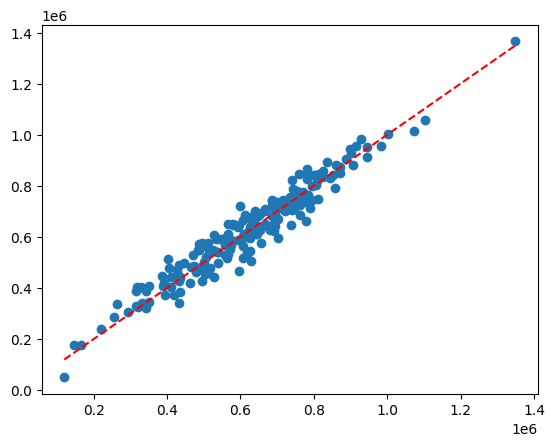

In [ ]:
plt.scatter(y_test_reg, previsao_reg)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], color='red', linestyle='--')
plt.show()

<small> Os resultados da Regressão Linear mostram como cada variável influencia o preço do imóvel. A área do apartamento tem uma relação positiva com o preço: a cada 1 m² a mais, o imóvel aumenta, em média, R$ 5.912,48.

Já a distância do marco zero tem uma relação negativa. A cada 1 km a mais de distância, o preço diminui, em média, R$ 2.153,92. Assim, os resultados mostram que tanto o tamanho quanto a localização têm um impacto importante no valor dos imóveis, ajudando a PropTech a tomar decisões de preço com base nos dados.</small>

### Fitting Motor Preditivo II — Classificação com Árvores de Decisão

In [ ]:
modelo_class = DecisionTreeClassifier(max_depth=None, random_state=42)

modelo_class.fit(X_train_class,y_train_class)

previsao_class = modelo_class.predict(X_test_class)

### Avaliação Modelo

In [ ]:
precisao = precision_score(y_test_class, previsao_class)
f1 = f1_score(y_test_class, previsao_class)

In [ ]:
acuracia = accuracy_score(y_test_class, previsao_class)
recall = recall_score(y_test_class, previsao_class)

print("acuracia:", acuracia)
print("Recall:", recall)

acuracia: 0.71
Recall: 0.32653061224489793


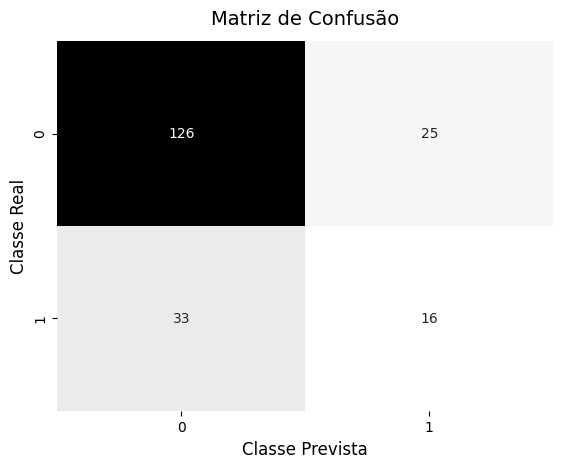

In [ ]:
matriz = confusion_matrix(y_test_class, previsao_class)
sns.heatmap(matriz, annot=True, fmt='g', cmap = 'Greys', cbar= False)
plt.title('Matriz de Confusão', fontsize=14, pad=12)
plt.xlabel('Classe Prevista', fontsize=12)
plt.ylabel('Classe Real', fontsize=12)
plt.show()

Análise Estratégica de Risco: Falso Positivo vs. Falso Negativo

<small> Para a estratégia de publicidade da PropTech, o Falso Positivo é o erro mais prejudicial. Isso acontece quando o modelo prevê que um imóvel será vendido em menos de 30 dias, mas ele acaba demorando mais. Nesse caso, a empresa pode gastar dinheiro com anúncios em um imóvel que já teria dificuldade para vender, gerando um desperdício do orçamento de marketing.

Já no Falso Negativo, o modelo prevê que o imóvel vai demorar para vender, mas ele acaba sendo vendido rapidamente. Nesse cenário, a empresa apenas deixa de aproveitar uma oportunidade de acelerar a venda. Por isso, para a estratégia de marketing, é importante reduzir os Falsos Positivos, evitando gastar dinheiro com anúncios em imóveis com baixa probabilidade de venda rápida.</small>

### Otimização do Hiperparâmetro (Overditting) - Modelo Classificação com Árvores de Decisão



In [ ]:
profundidades = [1, 3, 5, 10, None]

f1_treinos = []
f1_testes = []

for prof in profundidades:
    modelo_teste = DecisionTreeClassifier(max_depth=prof, random_state=42)

    modelo_teste.fit(X_train_class, y_train_class)

    prev_treino = modelo_teste.predict(X_train_class)
    prev_teste = modelo_teste.predict(X_test_class)

    nota_treino = f1_score(y_train_class, prev_treino)
    nota_teste = f1_score(y_test_class, prev_teste)

    f1_treinos.append(nota_treino)
    f1_testes.append(nota_teste)

tabela_resultados = pd.DataFrame({
    'Profundidade Máxima': ['1', '3', '5', '10', 'Livre (None)'],
    'F1-Score Treino': f1_treinos,
    'F1-Score Teste': f1_testes
})

display(tabela_resultados)

,Profundidade Máxima,F1-Score Treino,F1-Score Teste
0,1,0.547677,0.464646
1,3,0.565598,0.380952
2,5,0.628743,0.417582
3,10,0.899225,0.322581
4,Livre (None),0.997429,0.355556


Diagnóstico de Overfitting e Escolha da Profundidade

<small>A variação do hiperparâmetro max_depth ilustrou claramente o fenômeno de overfitting (sobreajuste). Quando treinamos a árvore com profundidade livre (None ou 10), o algoritmo simplesmente decorou os dados de treino, atingindo um F1-Score excepcionalmente alto (próximo de 99%), mas perdendo completamente a capacidade de generalização nos dados de teste, onde a performance caiu para cerca de 35%.

Por outro lado, a profundidade 1 gerou o efeito oposto, resultando em underfitting (modelo excessivamente simples). Analisando as métricas da tabela, a profundidade ideal escolhida para entrar em produção foi max_depth = 5. Este valor representa o ponto ótimo de equilíbrio: a árvore consegue capturar a complexidade necessária das características do imóvel para aprender a regra de negócio, mantendo o melhor desempenho possível nos dados inéditos de teste sem viciar na base de treino.</small>

### Treinando o Modelo Campeão (Profundidade 5)

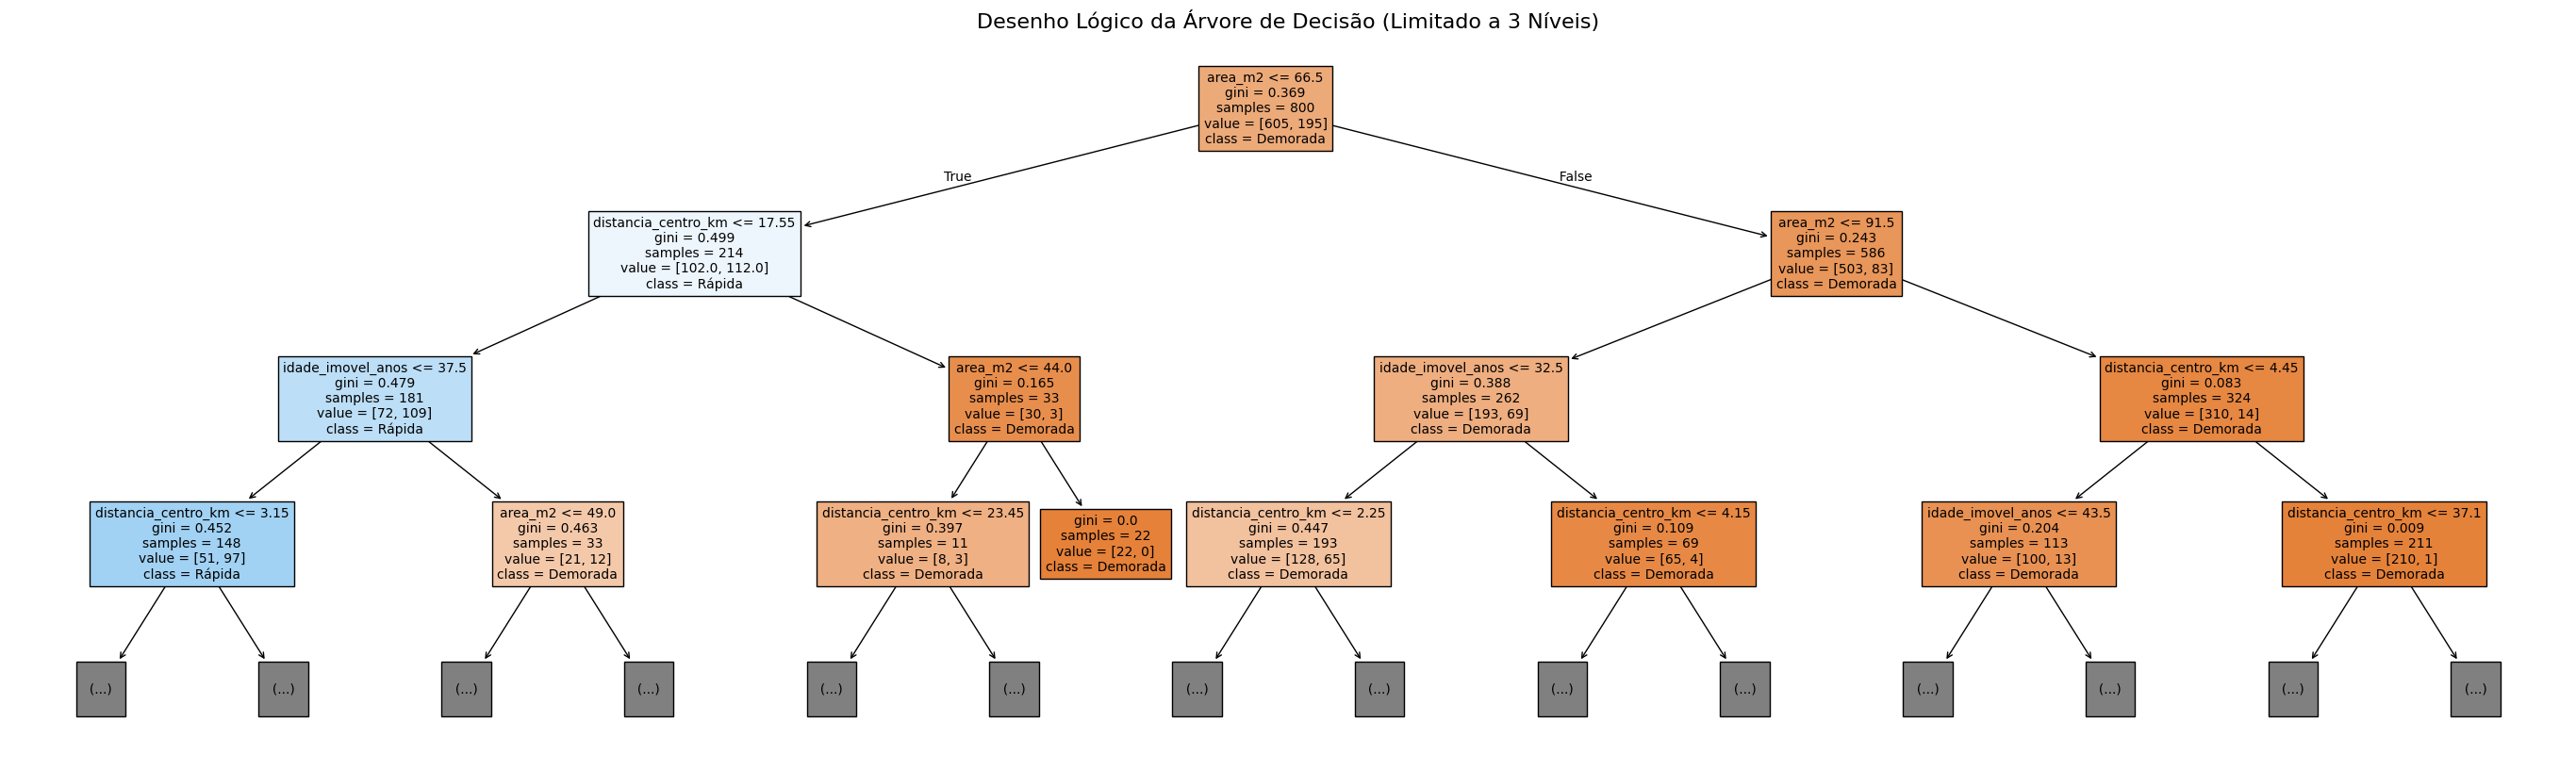

In [ ]:
modelo_arvore_final = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_arvore_final.fit(X_train_class, y_train_class)

plt.figure(figsize=(35, 10))

plot_tree(
    modelo_arvore_final,
    filled=True,
    feature_names=X_train_class.columns,
    class_names=['Demorada', 'Rápida'],
    max_depth=3,
    fontsize=10
)

plt.title("Desenho Lógico da Árvore de Decisão (Limitado a 3 Níveis)", fontsize=16)
plt.show()